# ONLINE DATING PROFİLLERİNDEN YAŞ VE KUŞAK TAHMİNİ

Bu projenin amacı, OKCupid kullanıcılarının profil verilerini (vücut tipi, diyet, eğitim, gelir vb.) kullanarak iki temel yapay zeka problemi çözmektir:

1) Regresyon (Regression): Kullanıcının profil özelliklerine bakarak yaşını (age) tahmin eden bir Derin Öğrenme modeli geliştirmek.
2) Sınıflandırma (Classification): Kullanıcının hangi kuşağa (Millennial, Gen X-er, Boomers) ait olduğunu tahmin eden bir Derin Öğrenme modeli geliştirmek.

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sklearn Kütüphaneleri
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report
from sklearn.utils import class_weight
from sklearn.feature_extraction.text import TfidfVectorizer 
from scipy.sparse import hstack 

# XGBoost Kütüphanesi
import xgboost as xgb 

# TensorFlow / Keras 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

In [177]:
df = pd.read_csv('profiles.csv')

In [178]:
df.shape

(60552, 31)

In [179]:
df.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22.0,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35.0,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38.0,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23.0,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29.0,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60552 entries, 0 to 60551
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          9514 non-null   float64
 1   body_type    8666 non-null   object 
 2   diet         5761 non-null   object 
 3   drinks       9012 non-null   object 
 4   drugs        7215 non-null   object 
 5   education    8459 non-null   object 
 6   essay0       8667 non-null   object 
 7   essay1       8347 non-null   object 
 8   essay2       8049 non-null   object 
 9   essay3       7690 non-null   object 
 10  essay4       7879 non-null   object 
 11  essay5       7814 non-null   object 
 12  essay6       7352 non-null   object 
 13  essay7       7553 non-null   object 
 14  essay8       6361 non-null   object 
 15  essay9       7554 non-null   object 
 16  ethnicity    8565 non-null   object 
 17  height       9514 non-null   float64
 18  income       9514 non-null   float64
 19  job 

In [181]:
df.isnull().sum()

age            51038
body_type      51886
diet           54791
drinks         51540
drugs          53337
education      52093
essay0         51885
essay1         52205
essay2         52503
essay3         52862
essay4         52673
essay5         52738
essay6         53200
essay7         52999
essay8         54191
essay9         52998
ethnicity      51987
height         51038
income         51038
job            52369
last_online    51038
location       51038
offspring      56666
orientation    51038
pets           54200
religion       54291
sex            51038
sign           52776
smokes         51956
speaks         51044
status         51038
dtype: int64

In [182]:
# İstatistiksel özet
df.describe()

,age,height,income
count,9514.000000,9514.000000,9514.000000
mean,32.084192,68.337398,18887.145155
std,9.445488,3.905229,91428.807808
min,18.000000,36.000000,-1.000000
25%,25.000000,66.000000,-1.000000
50%,30.000000,68.000000,-1.000000
75%,36.000000,71.000000,-1.000000
max,110.000000,95.000000,1000000.000000


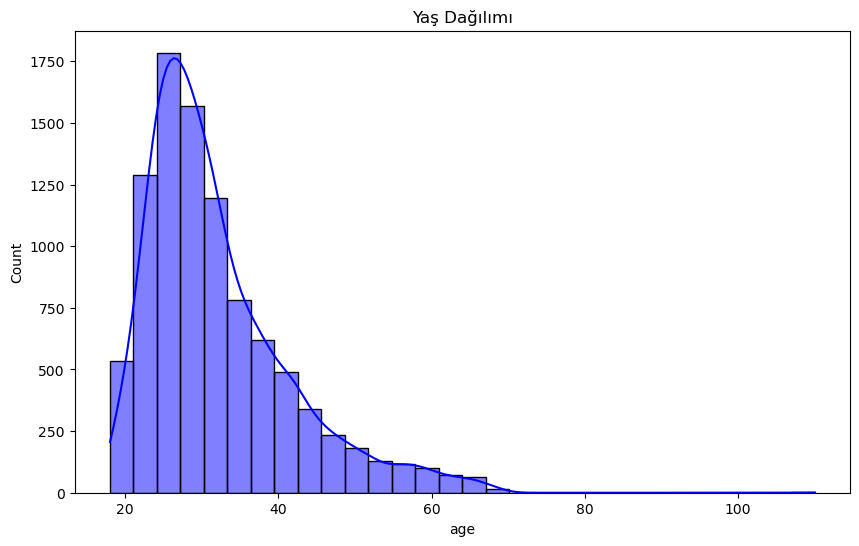

In [183]:
# Yaş dağılımını görselleştir
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title('Yaş Dağılımı')
plt.show()

In [184]:
# Kuşak Tanımlama Fonksiyonu
def map_generation(age):
    if 18 <= age <= 32: return 'Millennial'
    elif 33 <= age <= 47: return 'Gen X-er'
    elif 48 <= age <= 70: return 'Boomers'
    return 'Other'

In [185]:
# 1. df üzerinde filtreleme ve temizleme yapılıyor
df['generation'] = df['age'].apply(map_generation)
df = df[df['generation'] != 'Other']
df = df[df['age'] <= 90]
df['income'].replace(-1, np.nan, inplace=True)

In [186]:
# 2. df_raw'ın indeksi, df'in filtrelerden arta kalan indeksleriyle eslestiriliyor
df_raw = df_raw.loc[df.index] 
df_raw['generation'] = df_raw['age'].apply(map_generation)

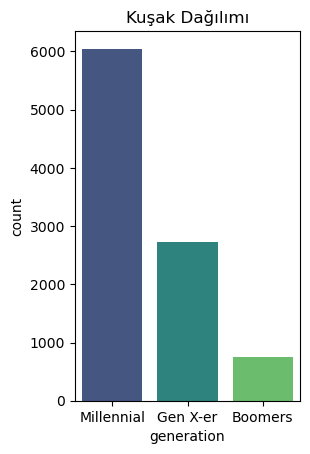

In [187]:
# Sınıflandırma için hedef değişkenimizin dağılımına bakalım
plt.subplot(1, 2, 2)
sns.countplot(x='generation', data=df, palette='viridis', order=['Millennial', 'Gen X-er', 'Boomers'])
plt.title('Kuşak Dağılımı')
plt.show()

### Feature Engineering

In [188]:
# Essay Sütunlarını Silmiyoruz! Uzunluklarını alıyoruz.
# Çünkü yaşlı insanlar daha uzun ve detaylı yazma eğilimindedir.
essay_cols = [f'essay{i}' for i in range(10)]
for col in essay_cols:
    df[col] = df[col].fillna('')
    df[f'{col}_len'] = df[col].apply(lambda x: len(x)) 
df.drop(columns=essay_cols, inplace=True)

In [189]:
# Gereksiz Sütunları Cikar
df.drop(columns=['last_online', 'location'], inplace=True, errors='ignore')

In [190]:
# Multivalue Özellikleri Parcalama

In [191]:
# Speaks
df['speaks_main'] = df['speaks'].str.split(',').str[0].str.split('(').str[0].str.strip()
df['speaks_count'] = df['speaks'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 1)
df.drop(columns=['speaks'], inplace=True, errors='ignore')

In [192]:
# Education
def parse_education(edu):
    if pd.isna(edu) or edu == '': return 'Unknown Degree', 'Unknown Status'
    parts = edu.split('from')
    degree_status = parts[0].strip()
    if 'working on' in degree_status: status = 'working on'
    elif 'graduated' in degree_status: status = 'graduated'
    else: status = 'completed'
    degree = degree_status.split('working on')[0].split('graduated')[0].strip().replace('a little', '').strip()
    if degree == '': degree = 'Unknown Degree'
    return degree.split('/')[0].strip(), status 

df[['education_degree', 'education_status']] = df['education'].apply(parse_education).apply(pd.Series)
df.drop(columns=['education'], inplace=True, errors='ignore')

In [193]:
# Sign Sadeleştirme
if 'sign' in df.columns:
    df['sign_cleaned'] = df['sign'].str.split().str[0]
    df.drop(columns=['sign'], inplace=True)

In [194]:
df

,age,body_type,diet,drinks,drugs,ethnicity,height,income,job,offspring,...,essay5_len,essay6_len,essay7_len,essay8_len,essay9_len,speaks_main,speaks_count,education_degree,education_status,sign_cleaned
0,22.0,a little extra,strictly anything,socially,never,"asian, white",75.0,NaN,transportation,"doesn&rsquo;t have kids, but might want them",...,51,27,78,71,153,english,1,Unknown Degree,working on,gemini
1,35.0,average,mostly other,often,sometimes,white,70.0,80000.0,hospitality / travel,"doesn&rsquo;t have kids, but might want them",...,306,0,0,50,0,english,3,Unknown Degree,working on,cancer
2,38.0,thin,anything,socially,NaN,NaN,68.0,NaN,NaN,NaN,...,86,0,59,58,268,english,3,Unknown Degree,graduated,pisces
3,23.0,thin,vegetarian,socially,NaN,white,71.0,20000.0,student,doesn&rsquo;t want kids,...,0,26,0,0,21,english,2,Unknown Degree,working on,pisces
4,29.0,athletic,NaN,socially,never,"asian, black, other",66.0,NaN,artistic / musical / writer,NaN,...,0,0,0,0,0,english,1,Unknown Degree,graduated,aquarius
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9509,28.0,athletic,strictly anything,socially,never,white,73.0,60000.0,medicine / health,"doesn&rsquo;t have kids, but wants them",...,625,45,34,583,622,english,2,Unknown Degree,working on,aries
9510,31.0,athletic,mostly anything,socially,sometimes,white,72.0,NaN,hospitality / travel,NaN,...,101,15,56,0,29,english,1,Unknown Degree,Unknown Status,scorpio
9511,34.0,average,NaN,socially,NaN,white,71.0,NaN,hospitality / travel,doesn&rsquo;t want kids,...,143,34,91,38,26,english,1,dropped out of college,completed,leo
9512,29.0,athletic,anything,rarely,never,white,70.0,NaN,NaN,"doesn&rsquo;t have kids, and doesn&rsquo;t wan...",...,0,0,0,0,0,english,3,two-year college,completed,aries


In [195]:
# Sütunları ayırma
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in ['age', 'generation']]
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ['age', 'generation']]

In [196]:
categorical_cols

['body_type',
 'diet',
 'drinks',
 'drugs',
 'ethnicity',
 'job',
 'offspring',
 'orientation',
 'pets',
 'religion',
 'sex',
 'smokes',
 'status',
 'speaks_main',
 'education_degree',
 'education_status',
 'sign_cleaned']

In [197]:
numerical_cols

['height',
 'income',
 'essay0_len',
 'essay1_len',
 'essay2_len',
 'essay3_len',
 'essay4_len',
 'essay5_len',
 'essay6_len',
 'essay7_len',
 'essay8_len',
 'essay9_len',
 'speaks_count']

#### NLP FEATURE ENGINEERING (TF-IDF) VE BİRLEŞTİRME

In [202]:
# Metinleri birleştir
essay_cols_original = [f'essay{i}' for i in range(10)]
df_raw['all_essays'] = df_raw[essay_cols_original].fillna('').agg(' '.join, axis=1)

In [203]:
# TF-IDF Vektörleştirici (5000 özellik)
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_features = tfidf.fit_transform(df_raw['all_essays'])

In [204]:
# X_scaled (Kategorik/Sayısal) ile TF-IDF özelliklerini birleştirme
X_final = hstack([X_scaled, tfidf_features]).tocsr()

In [205]:
X_final.shape

(9513, 5301)

### 1: YAŞ TAHMİNİ (REGRESSION)

Burada age değerini tahmin eden bir Yapay Sinir Ağı (ANN) kuracağız.

In [206]:
y_reg = df['age'].values

In [207]:
y_reg

array([22., 35., 38., ..., 34., 29., 49.], shape=(9513,))

In [208]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_final, y_reg, test_size=0.2, random_state=42)

In [209]:
# Model
model_reg = Sequential([
    Dense(1024, activation='relu', input_dim=X_train_r.shape[1]),
    BatchNormalization(), Dropout(0.5), 
    Dense(512, activation='relu'),
    BatchNormalization(), Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(1, activation='relu') 
])
model_reg.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

In [210]:
# Early Stopping (Gereksiz epoch'ları önlemek için)
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

In [211]:
history_reg = model_reg.fit(X_train_r, y_train_r, validation_data=(X_test_r, y_test_r), 
                            epochs=100, batch_size=128, callbacks=[early_stop], verbose=0)

In [212]:
y_pred_reg = model_reg.predict(X_test_r)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


In [213]:
print(f"Regression R2 Score (Regülarize ANN): {r2_score(y_test_r, y_pred_reg):.4f}")
print(f"Regression RMSE (Regülarize ANN): {np.sqrt(mean_squared_error(y_test_r, y_pred_reg)):.4f}")

Regression R2 Score (Regülarize ANN): 0.5009
Regression RMSE (Regülarize ANN): 6.2899


### 2: KUŞAK TAHMİNİ (CLASSIFICATION)

Burada kullanıcının hangi kuşağa ait olduğunu (Çok sınıflı sınıflandırma) tahmin edeceğiz.

In [214]:
le = LabelEncoder()
y_class_indices = le.fit_transform(df['generation'])

In [215]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_final, y_class_indices, test_size=0.2, random_state=42)

In [216]:
# Sınıf Ağırlıklarını Hesaplama ve XGBoost için Sample Weight olarak kullanma
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_class_indices),
    y=y_class_indices
)

In [217]:
# Her veri noktasına ait ağırlığı oluşturma (Dengesiz veri için kritik)
sample_weights = np.array([class_weights[i] for i in y_train_c])

In [218]:
# XGBoost Sınıflandırıcı
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax', 
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,            
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='merror'
)

In [219]:
# Modeli Sample Weight kullanarak eğitme
xgb_model.fit(X_train_c, y_train_c, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='merror',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [220]:
y_pred_xgb = xgb_model.predict(X_test_c)

In [221]:
print(f"\nClassification Accuracy (XGBoost): {accuracy_score(y_test_c, y_pred_xgb):.4f}")
print("\nClassification Report (XGBoost):")
print(classification_report(y_test_c, y_pred_xgb, target_names=le.classes_))


Classification Accuracy (XGBoost): 0.7020

Classification Report (XGBoost):
              precision    recall  f1-score   support

     Boomers       0.41      0.45      0.43       119
    Gen X-er       0.51      0.53      0.52       541
  Millennial       0.82      0.80      0.81      1243

    accuracy                           0.70      1903
   macro avg       0.58      0.59      0.59      1903
weighted avg       0.71      0.70      0.71      1903



Bu proje ile bir sosyal platformdaki kullanıcı profillerini (metinler, eğitim, vb.) analiz ederek Yaş Tahmini ve Kuşak Sınıflandırması yaptık.